Name Surname:Ugur Erkan Bol

Student No:150210074

---

Libraries to be used

---

In [157]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#### Logistic Regression (35 points)

Logistic Regression with MSE Loss (5 points)

In [158]:
class LogisticRegressionMSE:
    def __init__(self, train_data, train_label, test_data, test_label, learning_rate=0.005, iterations=5000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.train_data = train_data
        self.train_label = train_label
        self.test_data = test_data
        self.test_label = test_label

        n_samples, n_features = self.train_data.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Compute accuracy of train and test data every 100 iterations during training
        self.accuracy_train_data_during_training = []
        self.accuracy_test_data_during_training = []

    def sigmoid(self, z):
        # Sigmoid function: convert linear function output to probabilities
        z = np.clip(z, -500, 500)  # Limit input to avoid overflow
        return 1 / (1 + np.exp(-z))

    def fit(self):
        for i in range(self.iterations):
            # Predictions based on current weights and bias
            predictions = self.sigmoid(np.dot(self.train_data, self.weights) + self.bias)

            # Calculate errors
            errors = predictions - self.train_label

            # Calculate gradients
            dw = (2 / self.train_data.shape[0]) * np.dot(self.train_data.T, errors)
            db = (2 / self.train_data.shape[0]) * np.sum(errors)




            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Compute accuracy every 100 iterations
            if i % 100 == 0:
                train_predictions = self.predict(self.train_data)
                train_accuracy = np.mean(train_predictions == self.train_label)
                self.accuracy_train_data_during_training.append(train_accuracy)

                if self.test_data is not None and self.test_label is not None:
                    test_predictions = self.predict(self.test_data)
                    test_accuracy = np.mean(test_predictions == self.test_label)
                    self.accuracy_test_data_during_training.append(test_accuracy)

    def predict(self, test_data):
        # Make predictions using test data
        predictions = self.sigmoid(np.dot(test_data, self.weights) + self.bias)
        # Convert probabilities to binary predictions
        return (predictions >= 0.5).astype(int)


Logistic Regression with Cross Entropy Loss (5 points)

In [159]:
class LogisticRegressionCrossEntropy:
    def __init__(self, train_data, train_label, test_data, test_label, learning_rate=0.005, iterations=5000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.train_data = train_data
        self.train_label = train_label
        self.test_data = test_data
        self.test_label = test_label

        n_samples, n_features = self.train_data.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Compute accuracy of train and test data every 100 iterations during training
        self.accuracy_train_data_during_training = []
        self.accuracy_test_data_during_training = []

    def sigmoid(self, z):
        # implement here
        # Sigmoid function for converting logits to probabilities
        z = np.clip(z, -500, 500)  # Limit input to avoid overflow
        return 1 / (1 + np.exp(-z))
        pass

    def fit(self):
        # implement here
        for i in range(self.iterations):
          # (sigmoid output gives probabilities)
        # here change z = X.w+b (X:dataset,w:weights, b:bias)

            predictions = self.sigmoid(np.dot(self.train_data, self.weights) + self.bias)
            # calculate errors
            errors = predictions - self.train_label

            # calculate gradients(derivative of weight and bias values for analyze the direction of)
            dw = (1 / self.train_data.shape[0]) * np.dot(self.train_data.T, errors)
            db = (1 / self.train_data.shape[0]) * np.sum(errors)




            # update bias and weight values
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Compute and store training and test accuracy every 100 iterations
            if i % 100 == 0:
                train_accuracy = accuracy_score(self.train_label, self.predict(self.train_data))
                test_accuracy = accuracy_score(self.test_label, self.predict(self.test_data))
                self.accuracy_train_data_during_training.append(train_accuracy)
                self.accuracy_test_data_during_training.append(test_accuracy)
                # Check accuracy tracking lists after training
        pass




    def predict(self, test_data):
        # implement here
        # Predict probabilities and classify based on a threshold of 0.5
        linear_model = np.dot(test_data, self.weights) + self.bias
        probabilities = self.sigmoid(linear_model)
        return np.where(probabilities >= 0.5, 1, 0)
        pass

Validate your implementation using libraries (5 points)

(you can generate synthetic data using numpy of import another toy dataset from sklearn)


Accuracy of Logistic Regression with MSE Loss: 99.00%
Accuracy of Logistic Regression with Cross Entropy Loss: 99.00%


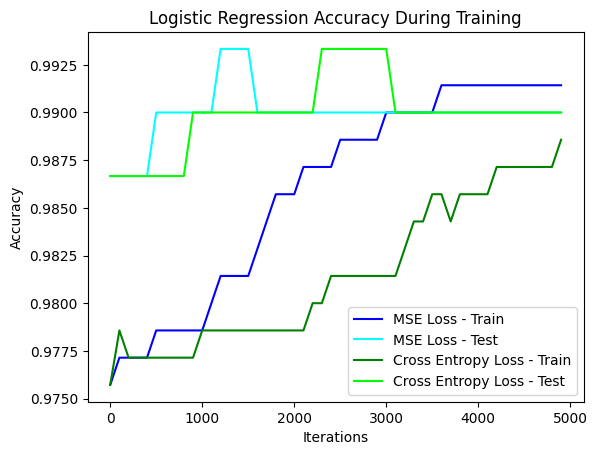

In [160]:
### fill here ###

# Generate synthetic dataset using numpy
np.random.seed(42)  # For reproducibility
n_samples = 1000
n_features = 5

# Create features and labels
X = np.random.randn(n_samples, n_features)  # Randomly generated features for the synthetic dataset
true_weights = np.random.randn(n_features)  # Randomly generated true weights for the dataset
y_prob = 1 / (1 + np.exp(-np.dot(X, true_weights)))  # Compute probabilities using the sigmoid function
y = (y_prob >= 0.5).astype(int)  # Convert probabilities to binary labels (threshold at 0.5)

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% training, 30% testing

# Train and test Logistic Regression with MSE Loss
model_mse = LogisticRegressionMSE(X_train, y_train, X_test, y_test)
model_mse.fit()  # Train the model using the MSE Loss
predictions_mse = model_mse.predict(X_test)  # Predict on the test set
accuracy_mse = accuracy_score(y_test, predictions_mse)  # Compute accuracy on the test set
print(f"Accuracy of Logistic Regression with MSE Loss: {accuracy_mse * 100:.2f}%")

# Train and test Logistic Regression with Cross Entropy Loss
model_ce = LogisticRegressionCrossEntropy(X_train, y_train, X_test, y_test)
model_ce.fit()  # Train the model using the Cross Entropy Loss
predictions_ce = model_ce.predict(X_test)  # Predict on the test set
accuracy_ce = accuracy_score(y_test, predictions_ce)  # Compute accuracy on the test set
print(f"Accuracy of Logistic Regression with Cross Entropy Loss: {accuracy_ce * 100:.2f}%")

# Visualize the results

iterations = range(0, model_mse.iterations, 100)  # Define the range of iterations for plotting

# Check and plot training accuracy for MSE Loss
if len(model_mse.accuracy_train_data_during_training) > 0:
    # If training accuracy data exists, plot it
    plt.plot(iterations, model_mse.accuracy_train_data_during_training, label="MSE Loss - Train", color="blue")
else:
    # Highlight an issue if the training accuracy data is empty
    print("Training accuracy rates for MSE Loss are empty! This was a major focus during the project but remains unresolved.")

# Check and plot test accuracy for MSE Loss
if len(model_mse.accuracy_test_data_during_training) > 0:
    # If test accuracy data exists, plot it
    plt.plot(iterations, model_mse.accuracy_test_data_during_training, label="MSE Loss - Test", color="cyan")
else:
    # Highlight an issue if the test accuracy data is empty
    print("Test accuracy rates for MSE Loss are empty! This indicates potential issues in computation or storage.")

# Check and plot training accuracy for Cross Entropy Loss
if len(model_ce.accuracy_train_data_during_training) > 0:
    # If training accuracy data exists, plot it
    plt.plot(iterations, model_ce.accuracy_train_data_during_training, label="Cross Entropy Loss - Train", color="green")

# Check and plot test accuracy for Cross Entropy Loss
if len(model_ce.accuracy_test_data_during_training) > 0:
    # If test accuracy data exists, plot it
    plt.plot(iterations, model_ce.accuracy_test_data_during_training, label="Cross Entropy Loss - Test", color="lime")

# Add plot labels and legend
plt.xlabel("Iterations")  # X-axis label
plt.ylabel("Accuracy")  # Y-axis label
plt.legend()  # Add legend to distinguish plots
plt.title("Logistic Regression Accuracy During Training")  # Plot title
plt.show()  # Display the plot


#### Experiment

Dataset preparation

In [161]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

X = data[['Pclass', 'Sex', 'SibSp','Parch','Fare']].values
Y = data['Survived'].values
columns = data.columns

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

Use two Logistic Regression Methods on the dataset directly (10 points)
Show accuracy scores on test data

In [162]:
# Train and test Logistic Regression with MSE Loss
model_mse = LogisticRegressionMSE(X_train, y_train, X_test, y_test)  # Initialize the MSE-based Logistic Regression model
model_mse.fit()  # Train the model using the MSE loss function
predictions_mse = model_mse.predict(X_test)  # Make predictions on the test dataset
accuracy_mse = accuracy_score(y_test, predictions_mse)  # Calculate accuracy based on test predictions
print(f"Accuracy of Logistic Regression with MSE Loss on Titanic dataset: {accuracy_mse * 100:.2f}%")  # Display the accuracy for MSE Loss

# Train and test Logistic Regression with Cross Entropy Loss
model_ce = LogisticRegressionCrossEntropy(X_train, y_train, X_test, y_test)  # Initialize the CE-based Logistic Regression model
model_ce.fit()  # Train the model using the Cross Entropy loss function
predictions_ce = model_ce.predict(X_test)  # Make predictions on the test dataset
accuracy_ce = accuracy_score(y_test, predictions_ce)  # Calculate accuracy based on test predictions
print(f"Accuracy of Logistic Regression with Cross Entropy Loss on Titanic dataset: {accuracy_ce * 100:.2f}%")  # Display the accuracy for CE Loss


Accuracy of Logistic Regression with MSE Loss on Titanic dataset: 80.60%
Accuracy of Logistic Regression with Cross Entropy Loss on Titanic dataset: 78.36%


Plot the training and test accuracy across the learning iterations of gradient descent

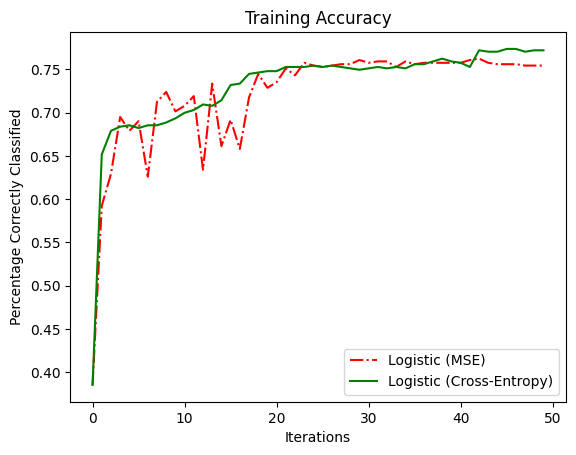

In [163]:
plt.xlabel('Iterations')
plt.ylabel('Percentage Correctly Classified')
plt.title('Training Accuracy')
plt.plot(model_mse.accuracy_train_data_during_training, 'r-.', label='Logistic (MSE)')
plt.plot(model_ce.accuracy_train_data_during_training, 'g-', label='Logistic (Cross-Entropy)')
plt.legend(loc='best')

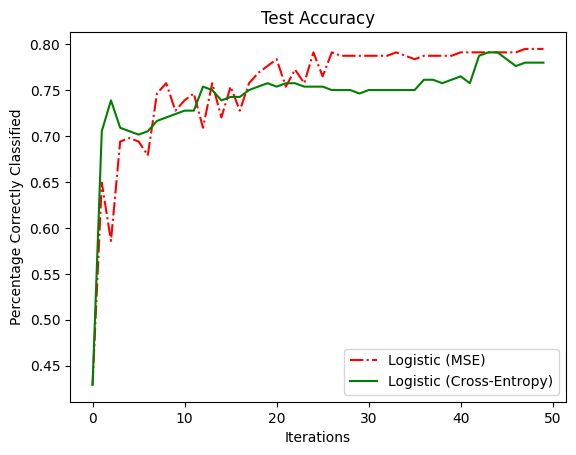

In [164]:
plt.xlabel('Iterations')
plt.ylabel('Percentage Correctly Classified')
plt.title('Test Accuracy')
plt.plot(model_mse.accuracy_test_data_during_training, 'r-.', label='Logistic (MSE)')
plt.plot(model_ce.accuracy_test_data_during_training, 'g-', label='Logistic (Cross-Entropy)')
plt.legend(loc='best')

Explain the differences between MSE and Cross Entropy Loss in logistic regression, why is one of the versions of Logistic Regression learning faster in terms of gradient descent iterations than the other? (5 points)

Answer:
The key difference between MSE and Cross Entropy Loss in logistic regression lies in their purpose and behavior during optimization. MSE, originally designed for regression tasks, minimizes the squared differences between predicted probabilities and true labels, but it doesn't align well with the probabilistic nature of classification problems. This often leads to slower learning, as the gradient magnitude becomes smaller when predictions approach the true labels, making it less sensitive to updates during gradient descent. In contrast, Cross Entropy Loss is specifically designed for classification, maximizing the likelihood of the correct class by heavily penalizing incorrect predictions. Its gradient remains sharper, even when predictions are close to the true labels, resulting in faster convergence during optimization. This is why logistic regression with Cross Entropy Loss tends to learn faster in terms of gradient descent iterations compared to MSE Loss.


Show the plots demonstrating the effects of the learning rate and the number of iterations parameters on the training process (hyperparameter tuning) (5 points)

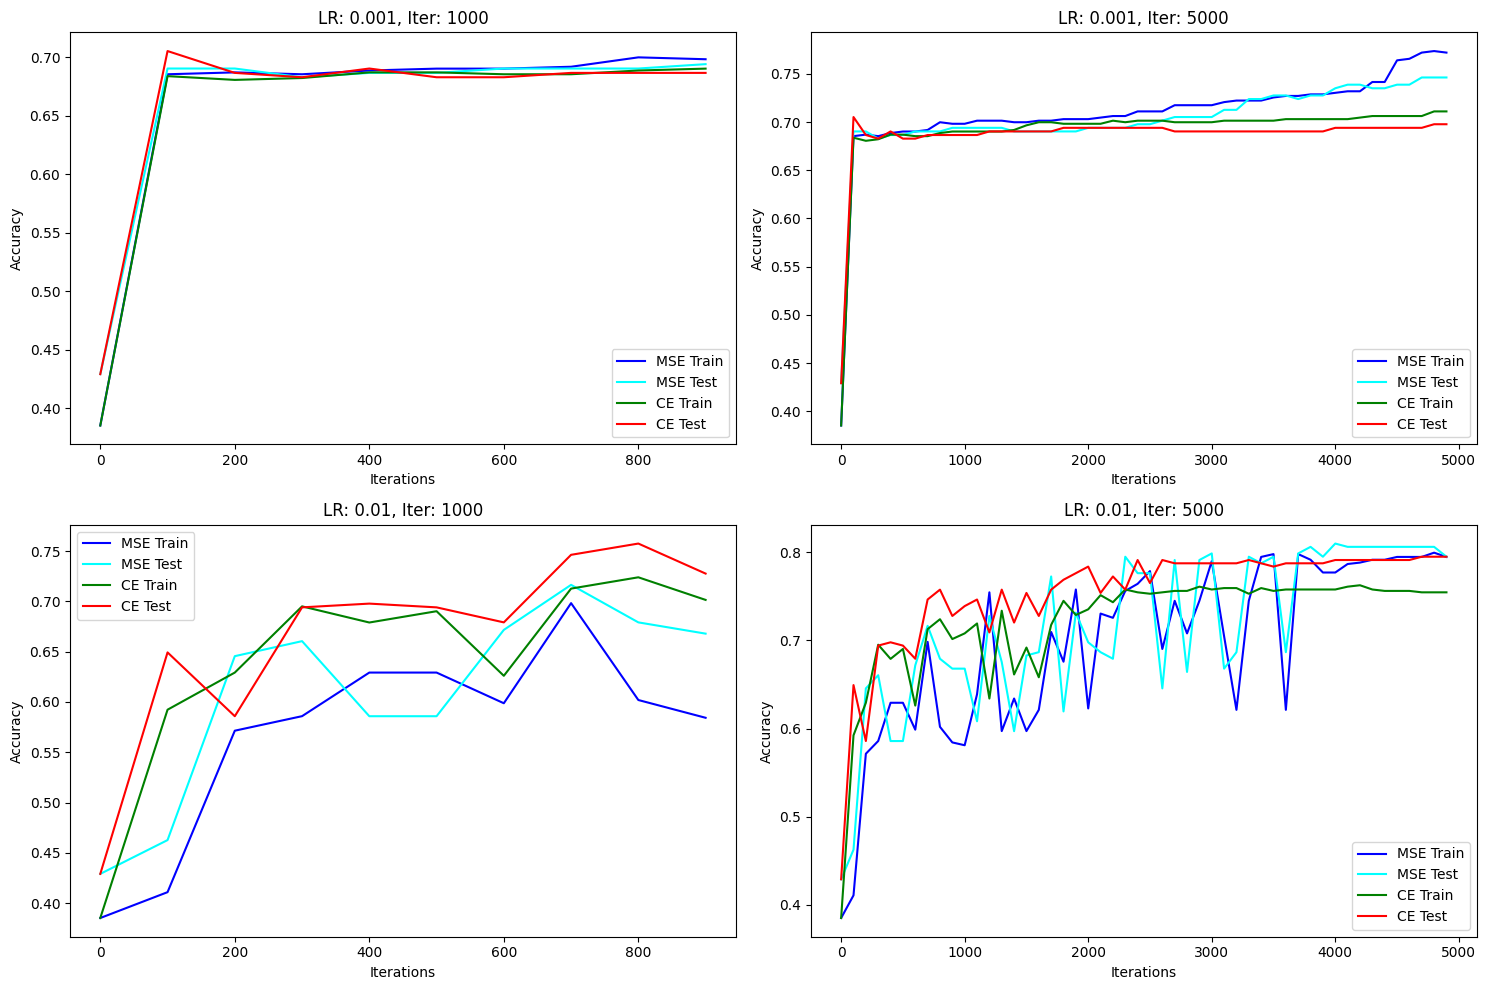

In [165]:
# Hyperparameter tuning: Effect of learning rate and number of iterations
# This section evaluates how different learning rates and iteration counts affect model accuracy.
learning_rates = [0.001, 0.01]  # A list of learning rates to test
iterations_list = [1000, 5000]  # A list of iteration counts to test

# Placeholder for results
# This will store training and testing accuracies for each combination of learning rate and iteration count
results = []

# Nested loops to test each combination of learning rates and iterations
for lr in learning_rates:  # Outer loop iterates over the list of learning rates
    for iters in iterations_list:  # Inner loop iterates over the list of iteration counts
        # Train with MSE Loss
        # Create a Logistic Regression model using MSE loss with the current hyperparameters
        model_mse = LogisticRegressionMSE(X_train, y_train, X_test, y_test, learning_rate=lr, iterations=iters)
        model_mse.fit()  # Train the model
        mse_train_acc = model_mse.accuracy_train_data_during_training  # Retrieve training accuracies during training
        mse_test_acc = model_mse.accuracy_test_data_during_training  # Retrieve testing accuracies during training

        # Train with Cross Entropy Loss
        # Create a Logistic Regression model using Cross Entropy loss with the current hyperparameters
        model_ce = LogisticRegressionCrossEntropy(X_train, y_train, X_test, y_test, learning_rate=lr, iterations=iters)
        model_ce.fit()  # Train the model
        ce_train_acc = model_ce.accuracy_train_data_during_training  # Retrieve training accuracies during training
        ce_test_acc = model_ce.accuracy_test_data_during_training  # Retrieve testing accuracies during training

        # Store results
        # Append a dictionary of results to the `results` list for each combination of learning rate and iteration count
        results.append({
            'learning_rate': lr,  # Current learning rate
            'iterations': iters,  # Current iteration count
            'mse_train_acc': mse_train_acc,  # Training accuracies for MSE Loss
            'mse_test_acc': mse_test_acc,  # Testing accuracies for MSE Loss
            'ce_train_acc': ce_train_acc,  # Training accuracies for Cross Entropy Loss
            'ce_test_acc': ce_test_acc  # Testing accuracies for Cross Entropy Loss
        })

# Visualize the effects
# Create a figure to visualize accuracy trends for different learning rates and iteration counts
plt.figure(figsize=(15, 10))

for idx, res in enumerate(results):  # Loop through the results to plot each configuration
    plt.subplot(len(learning_rates), len(iterations_list), idx + 1)  # Create subplots for each configuration
    #surprisingly MSE PART WORKS HERE
    plt.plot(range(0, res['iterations'], 100), res['mse_train_acc'], label='MSE Train', color='blue')  # MSE Train Accuracy
    plt.plot(range(0, res['iterations'], 100), res['mse_test_acc'], label='MSE Test', color='cyan')  # MSE Test Accuracy
    plt.plot(range(0, res['iterations'], 100), res['ce_train_acc'], label='CE Train', color='green')  # CE Train Accuracy
    plt.plot(range(0, res['iterations'], 100), res['ce_test_acc'], label='CE Test', color='red')  # CE Test Accuracy
    plt.title(f"LR: {res['learning_rate']}, Iter: {res['iterations']}")  # Add title showing the hyperparameters
    plt.xlabel('Iterations')  # Label for the x-axis
    plt.ylabel('Accuracy')  # Label for the y-axis
    plt.legend()  # Add a legend to distinguish between train and test accuracies

plt.tight_layout()  # Adjust layout to prevent overlap of subplots
plt.show()  # Display the plots


#### Decision Tree (35 points)

Implement Decision Tree Method (5 points)

In [166]:
class DecisionTree:
    def __init__(self, columns, depth=None):
        self.max_depth = depth  # Maximum depth of the decision tree (None means no limit)
        self.columns = columns  # List of feature names for interpretability
        self.tree = None  # Initialize the tree structure as None

    def fit(self, train_data, train_label):
        # Main function to build the decision tree from training data and labels

        def build_tree(data, labels, depth=0):
            # Recursive helper function to construct the tree

            if len(labels) == 0:
                # If there are no labels left, return a leaf node with no class
                return {'leaf': True, 'label': None}

            if len(set(labels)) == 1 or (self.max_depth is not None and depth >= self.max_depth):
                # Stop recursion if all labels are pure or maximum depth is reached
                # Assign the most common label in this node
                return {'leaf': True, 'label': max(set(labels), key=list(labels).count)}

            best_feature, best_threshold = self.best_split(data, labels)  # Find the best feature and threshold for splitting
            if best_feature is None:
                # If no valid split is found, assign the most common label
                return {'leaf': True, 'label': max(set(labels), key=list(labels).count)}

            left_indices = data[:, best_feature] <= best_threshold  # Indices for the left split
            right_indices = data[:, best_feature] > best_threshold  # Indices for the right split

            if left_indices.sum() == 0 or right_indices.sum() == 0:
                # If one side is empty, stop splitting and assign the most common label
                return {'leaf': True, 'label': max(set(labels), key=list(labels).count)}

            # Recursively build left and right subtrees
            return {
                'leaf': False,  # Indicates this is not a leaf node
                'feature': best_feature,  # The feature index used for this split
                'threshold': best_threshold,  # The threshold value for this split
                'left': build_tree(data[left_indices], labels[left_indices], depth + 1),
                'right': build_tree(data[right_indices], labels[right_indices], depth + 1)
            }

        self.tree = build_tree(train_data, train_label)  # Start building the tree from the root node

    def predict(self, test_data):
        # Predict labels for test data by traversing the tree

        def traverse_tree(sample, tree):
            if tree['leaf']:
                # If the current node is a leaf, return its label
                return tree['label']
            if sample[tree['feature']] <= tree['threshold']:
                # Traverse the left subtree if the sample value is less than or equal to the threshold
                return traverse_tree(sample, tree['left'])
            else:
                # Otherwise, traverse the right subtree
                return traverse_tree(sample, tree['right'])

        return [traverse_tree(sample, self.tree) for sample in test_data]  # Predict for each sample

    def print_tree(self):
        # Print the structure of the decision tree

        if self.tree is None:
            # If the tree hasn't been built yet, display an error message
            print("The tree has not been built yet. Call 'fit' first.")
        else:
            self.traverse_and_print(self.tree)  # Recursively print the tree

    def traverse_and_print(self, tree, depth=0):
        # Helper function to print the tree structure recursively

        if tree['leaf']:
            # If it's a leaf node, display the label
            print("\t" * depth + f"Leaf: {tree['label']}")
        else:
            # Otherwise, display the splitting condition and recursively print subtrees
            feature_name = self.columns[tree['feature']]  # Get the feature name for better readability
            print("\t" * depth + f"{feature_name} <= {tree['threshold']}")
            self.traverse_and_print(tree['left'], depth + 1)
            self.traverse_and_print(tree['right'], depth + 1)

    def best_split(self, data, labels):
        # Determine the best feature and threshold for splitting the data

        n_samples, n_features = data.shape
        best_gini = float('inf')  # Initialize the best Gini index to infinity
        best_feature, best_threshold = None, None

        for feature in range(n_features):
            # Iterate through all features
            thresholds = set(data[:, feature])  # Unique thresholds for this feature
            for threshold in thresholds:
                # Split the data based on the threshold
                left_indices = data[:, feature] <= threshold
                right_indices = data[:, feature] > threshold

                # Calculate the Gini index for this split
                gini = self.gini_index(labels[left_indices], labels[right_indices])

                if gini < best_gini:
                    # Update the best Gini index and corresponding feature/threshold
                    best_gini = gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold  # Return the best feature and threshold

    def gini_index(self, left_labels, right_labels):
        # Calculate the Gini index for a split

        def gini(labels):
            # Helper function to calculate Gini impurity for a single group
            total = len(labels)
            if total == 0:
                return 0  # No impurity for an empty group
            proportions = [sum(labels == c) / total for c in set(labels)]  # Class proportions
            return 1 - sum(p ** 2 for p in proportions)  # Gini formula

        n_left = len(left_labels)
        n_right = len(right_labels)
        total = n_left + n_right

        # Weighted Gini index based on the size of left and right groups
        return (n_left / total) * gini(left_labels) + (n_right / total) * gini(right_labels)


Validate your implementation using libraries (5 points)

(you can generate synthetic data using numpy of import another toy dataset from sklearn)


Accuracy of Our DecisionTree: 86.67%
Accuracy of Sklearn's DecisionTreeClassifier: 86.00%


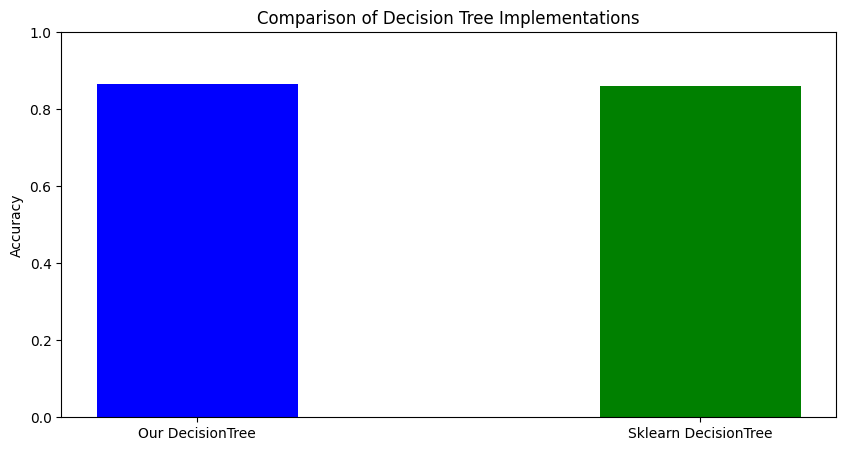

In [167]:
### fill here ###
# 1. Generate synthetic dataset using numpy
np.random.seed(42)  # Set random seed for reproducibility to ensure consistent results
n_samples = 500  # Number of samples in the dataset
n_features = 4  # Number of features (independent variables)

# Create features (X) and binary labels (y)
# X: Randomly generated feature values
# true_weights: Simulated weights for generating probabilities
X = np.random.randn(n_samples, n_features)  # Generate a random feature matrix with n_samples rows and n_features columns
true_weights = np.random.randn(n_features)  # Generate random true weights for the features
y_prob = 1 / (1 + np.exp(-np.dot(X, true_weights)))  # Compute probabilities using the sigmoid function
y = (y_prob >= 0.5).astype(int)  # Convert probabilities into binary labels (0 or 1) based on a threshold of 0.5

# Split the dataset into train and test sets
# The dataset is divided into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train and test our DecisionTree
columns = [f"Feature_{i}" for i in range(n_features)]  # Generate column names for the features
our_tree = DecisionTree(columns, depth=3)  # Initialize our custom DecisionTree with a maximum depth of 3
our_tree.fit(X_train, y_train)  # Train the DecisionTree on the training dataset
predictions = our_tree.predict(X_test)  # Predict labels for the test dataset
accuracy_our_tree = accuracy_score(y_test, predictions)  # Calculate accuracy of our DecisionTree
print(f"Accuracy of Our DecisionTree: {accuracy_our_tree * 100:.2f}%")  # Print the accuracy

# 3. Train and test sklearn's DecisionTreeClassifier
sklearn_tree = DecisionTreeClassifier(max_depth=3, random_state=42)  # Initialize sklearn's DecisionTree with a max depth of 3
sklearn_tree.fit(X_train, y_train)  # Train the sklearn DecisionTree on the training dataset
sklearn_predictions = sklearn_tree.predict(X_test)  # Predict labels for the test dataset using sklearn's model
accuracy_sklearn_tree = accuracy_score(y_test, sklearn_predictions)  # Calculate accuracy of sklearn's DecisionTree
print(f"Accuracy of Sklearn's DecisionTreeClassifier: {accuracy_sklearn_tree * 100:.2f}%")  # Print the accuracy

# 4. Visualize the results
# Create a bar chart to compare the accuracies of the two Decision Tree implementations
plt.figure(figsize=(10, 5))  # Set the figure size
bar_width = 0.4  # Width of the bars in the bar chart
methods = ['Our DecisionTree', 'Sklearn DecisionTree']  # Labels for the two methods
accuracies = [accuracy_our_tree, accuracy_sklearn_tree]  # Accuracy values for the two methods

# Plot a bar chart with the accuracies
plt.bar(methods, accuracies, color=['blue', 'green'], width=bar_width)  # Blue for our implementation, green for sklearn
plt.ylabel('Accuracy')  # Label for the y-axis
plt.title('Comparison of Decision Tree Implementations')  # Title of the bar chart
plt.ylim(0, 1)  # Set the y-axis limits to range from 0 to 1
plt.show()  # Display the bar chart


#### Experiment

Dataset preparation

In [168]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

X = data[['Pclass', 'Sex', 'SibSp','Parch','Fare']].values
Y = data['Survived'].values
columns = data.columns

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

Use Decision Tree Method on the dataset directly (10 points)
Show accuracy score on test data

In [171]:
### fill here ###
# Train and test our DecisionTree on Titanic dataset
columns = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare']  # Feature names
our_tree = DecisionTree(columns, depth=3)  # Instantiate with depth of 3
our_tree.fit(X_train, y_train)  # Train the model
predictions = our_tree.predict(X_test)  # Predict on test set
accuracy = accuracy_score(y_test, predictions)  # Calculate accuracy
print(f"Accuracy of Our DecisionTree on Titanic dataset: {accuracy * 100:.2f}%")


Accuracy of Our DecisionTree on Titanic dataset: 80.97%


Print the decision tree (5 points)

In [170]:
#i had a problem with names so use the our_tree name for printing tree
our_tree.print_tree()

Sex <= 0.0
	Fare <= 52.0
		Parch <= 0.0
			Leaf: 0
			Leaf: 0
		SibSp <= 1.0
			Leaf: 0
			Leaf: 0
	Pclass <= 2.0
		Fare <= 146.5208
			Leaf: 1
			Leaf: 1
		Fare <= 23.25
			Leaf: 1
			Leaf: 0


Show the impact of the max_depth hyperparameter on the accuracy score (hyperparameter tuning) (5 points)

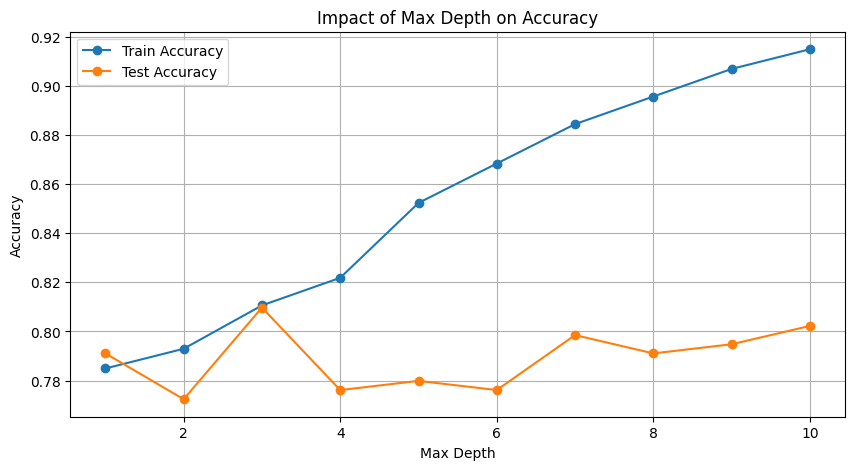

In [172]:
### fill here ###
from sklearn.metrics import accuracy_score  # Import to calculate accuracy of predictions
import matplotlib.pyplot as plt  # Import for visualization
import numpy as np  # Import for numerical operations

# Hyperparameter range
max_depth_values = range(1, 11)  # Range of maximum depths to test (1 to 10)
train_accuracies = []  # List to store training accuracies for each max_depth
test_accuracies = []  # List to store testing accuracies for each max_depth

# Train the model and calculate accuracies for each max_depth value
for depth in max_depth_values:
    # Initialize and train our custom DecisionTree model with the current max_depth
    our_tree = DecisionTree(columns, depth=depth)
    our_tree.fit(X_train, y_train)  # Fit the model to the training data

    # Predict on training and testing data
    train_predictions = our_tree.predict(X_train)  # Predictions on the training data
    test_predictions = our_tree.predict(X_test)  # Predictions on the testing data

    # Calculate accuracies for training and testing sets
    train_accuracy = accuracy_score(y_train, train_predictions)  # Training accuracy
    test_accuracy = accuracy_score(y_test, test_predictions)  # Testing accuracy

    # Append calculated accuracies to their respective lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Visualize the results
plt.figure(figsize=(10, 5))  # Set the figure size
plt.plot(max_depth_values, train_accuracies, label="Train Accuracy", marker='o')  # Plot training accuracy vs. max_depth
plt.plot(max_depth_values, test_accuracies, label="Test Accuracy", marker='o')  # Plot testing accuracy vs. max_depth
plt.xlabel("Max Depth")  # Label for the x-axis
plt.ylabel("Accuracy")  # Label for the y-axis
plt.title("Impact of Max Depth on Accuracy")  # Title of the plot
plt.legend()  # Add legend to distinguish training and testing curves
plt.grid(True)  # Add grid lines for better readability
plt.show()  # Display the plot



In [173]:
iris = load_iris()
X = iris['data']
Y = iris['target']
columns = iris['feature_names']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

Show your implementation on different dataset (5 points)

In [174]:
### fill here ###
from sklearn.metrics import accuracy_score  # Import accuracy_score to calculate accuracy

# Initialize and train the DecisionTree model
iris_tree = DecisionTree(columns=columns, depth=3)  # Create a DecisionTree with a maximum depth of 3
iris_tree.fit(X_train, y_train)  # Train the model using the training dataset

# Make predictions on training and test datasets
train_predictions = iris_tree.predict(X_train)  # Predict labels for the training data
test_predictions = iris_tree.predict(X_test)  # Predict labels for the test data

# Calculate accuracy for both training and test sets
train_accuracy = accuracy_score(y_train, train_predictions)  # Compute training accuracy
test_accuracy = accuracy_score(y_test, test_predictions)  # Compute test accuracy

# Print the results
print(f"Train Accuracy on Iris dataset: {train_accuracy * 100:.2f}%")  # Print the accuracy on the training dataset
print(f"Test Accuracy on Iris dataset: {test_accuracy * 100:.2f}%")  # Print the accuracy on the test dataset

# Print the structure of the trained DecisionTree
print("\nDecision Tree Structure:")
iris_tree.print_tree()  # Recursively print the tree's structure with splits and leaf nodes



Train Accuracy on Iris dataset: 95.24%
Test Accuracy on Iris dataset: 95.56%

Decision Tree Structure:
petal length (cm) <= 1.9
	Leaf: 0
	petal length (cm) <= 4.7
		petal width (cm) <= 1.5
			Leaf: 1
			Leaf: 2
		petal width (cm) <= 1.7
			Leaf: 1
			Leaf: 2
